# Saed Swidan 
# BI Student 
# Bank Data Visualzation and preprocessing

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from pandas.plotting import scatter_matrix
%matplotlib inline
plt.style.use('ggplot')
from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns
from scipy.stats import chi2_contingency
pd.set_option('display.max_columns', None)
from pathlib import Path 
path=Path("bank.csv").resolve()

In [132]:
df=pd.read_csv(path)

# looking into the Data

In [52]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [53]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [54]:
df.tail

<bound method NDFrame.tail of        age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campaig

In [55]:
df.describe

<bound method NDFrame.describe of        age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  cam

# Data set dimensions 

In [56]:
# Shape and columns 

In [57]:
print("Dataset shape:", df.shape)

print("\nFeatures:\n", df.columns)

Dataset shape: (11162, 17)

Features:
 Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [58]:
# Distrubution 

In [59]:
print("\nClass distribution:\n", df['poutcome'].value_counts())


Class distribution:
 poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64


In [60]:
# type and categroical features 

In [61]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [62]:
# numerical values 
 #day           int64
 # duration      int64
# campaign      int64
 # pdays         int64
# previous      int64

In [63]:
df.describe

<bound method NDFrame.describe of        age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  cam

# endcoding

In [64]:
# truning categorical data into numerical data  

In [65]:
categorical= df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical, drop_first=True)

df_encoded.head()


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,deposit_yes
0,59,2343,5,1042,1,-1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
1,56,45,5,1467,1,-1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
2,41,1270,5,1389,1,-1,0,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
3,55,2476,5,579,1,-1,0,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
4,54,184,5,673,2,-1,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True


In [66]:
pwd

'C:\\Users\\sweid'

In [67]:
# Checking for Missing Values

In [68]:
print("Missing values:\n", df.isnull().sum())
df.isnull().sum().sum()

Missing values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


np.int64(0)

In [69]:
#checking for any duplicate rows 
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


# Visual Charts  

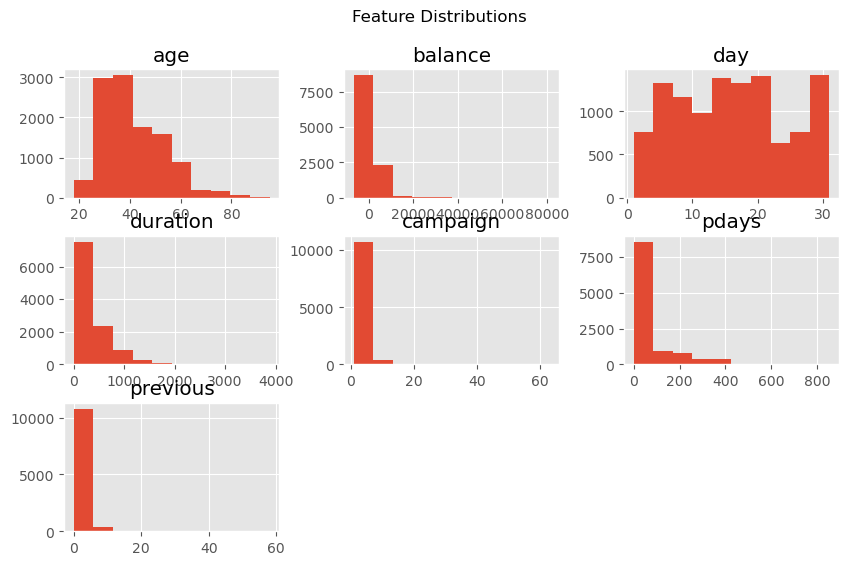

In [70]:
df.hist(figsize=(10,6))
plt.suptitle("Feature Distributions")
plt.show()

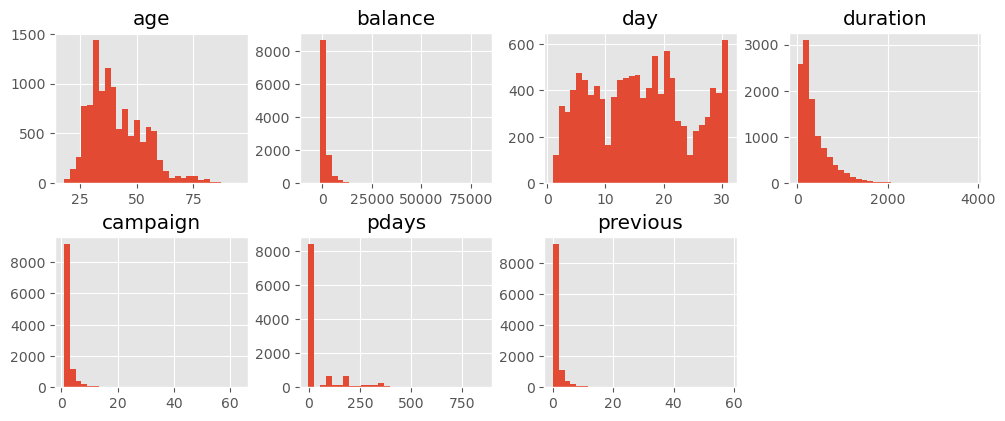

In [71]:
df.hist(bins=30,layout=(4, 4),figsize=(10, 8),sharex=False,sharey=False)
plt.tight_layout(pad=0.5, h_pad=0.5, w_pad=0.5)
#plt.tight_layout()
plt.show()

In [72]:
# Now I will detect any outlier before standardization or normalization 

# Outilers 

In [73]:
import pandas as pd
import numpy as np

# Assuming your DataFrame is called df
# Exclude 'CLASS' since it's categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Dictionary to store outliers per column
outliers_dict = {}
lower = {}
upper = {}
outlier_flags = pd.DataFrame(False, index=df.index, columns=numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower[col] = Q1 - 1.5 * IQR
    upper[col] = Q3 + 1.5 * IQR
    # Boolean mask for outliers
    outliers = df[(df[col] < lower[col]) | (df[col] > upper[col])][col]
    outliers_dict[col] = outliers.values
# mark outliers
    outlier_flags[col] = (df[col] < lower[col]) | (df[col] > upper[col])
# Example: print outliers for each column
for col, values in outliers_dict.items():
    print(f"{col} outliers: {values}")

age outliers: [75 85 90 85 83 76 83 77 77 76 78 95 78 75 76 85 83 79 82 79 75 76 82 77
 86 76 79 83 77 84 83 75 77 76 77 87 76 92 78 82 76 77 76 81 75 80 87 76
 82 77 76 81 75 78 80 86 79 79 81 75 84 87 85 79 92 77 81 80 77 78 76 80
 77 76 75 82 80 78 90 83 80 82 80 84 86 75 76 77 76 77 80 77 78 75 84 78
 80 80 79 86 93 82 82 77 93 77 75 80 84 75 78 81 81 77 78 75 77 77 77 78
 77 79 78 75 80 76 78 79 75 77 79 78 88 77 85 78 80 82 75 77 78 78 76 81
 77 75 80 80 80 76 77 81 76 76 87 81 78 82 83 77 77 75 76 89 80 77 77 88
 77 78 86]
balance outliers: [5090 7180 5291 ... 4243 6445 6242]
day outliers: []
duration outliers: [1042 1467 1389 1201 1297 1574 1689 1102 1084 1119 1120 2087 1120 1692
 1346 1721 1553 1328 1125 1423 1162 1224 1156 1052 1867 1143 1340 1297
 1193 1064 1187 1622 1205 1882 1334 1777 1182 1045 1063 1392 1681 1697
 1349 1392 1560 1234 1272 1063 1051 3094 1560 1183 1730 1207 1363 1109
 1133 1269 1097 1236 1343 1980 1044 1193 1036 1068 1173 1045 2456 1363
 1336 1449 1446 114

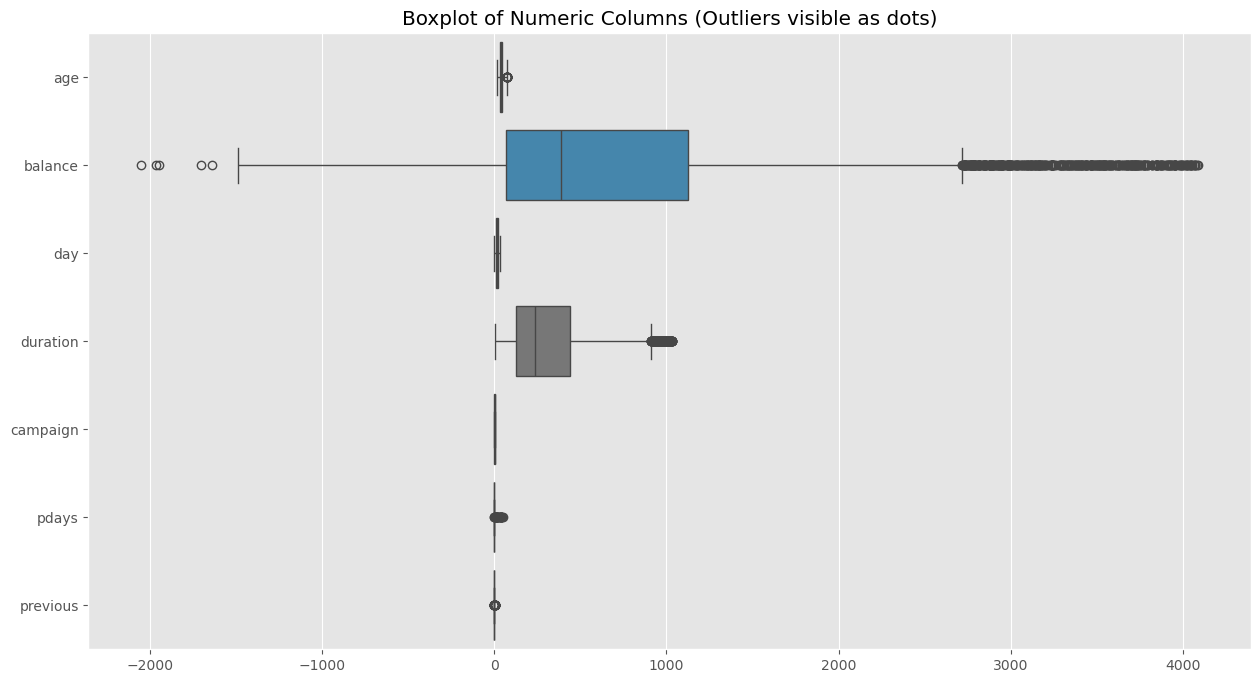

In [74]:
clean_df = df[~outlier_flags.any(axis=1)]
plt.figure(figsize=(15, 8))
sns.boxplot(data=clean_df[numeric_cols], orient='h')
plt.title("Boxplot of Numeric Columns (Outliers visible as dots)")
plt.show()

In [75]:
# Now I will standerize the data 

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('poutcome', axis=1)
y = df['poutcome']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit ONLY on training
X_test = scaler.transform(X_test)         # apply same transformation

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)


In [77]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8929, 40)
Test shape: (2233, 40)


In [78]:
pwd

'C:\\Users\\sweid'

# K Means clustering for the bank data(grouping)

In [79]:
# Apply K-Means (drop Lables)

In [80]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Drop target columns
X_kmeans = df.drop(['poutcome', 'deposit'], axis=1, errors='ignore')

# Encodes
X_kmeans = pd.get_dummies(X_kmeans, drop_first=True)

# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

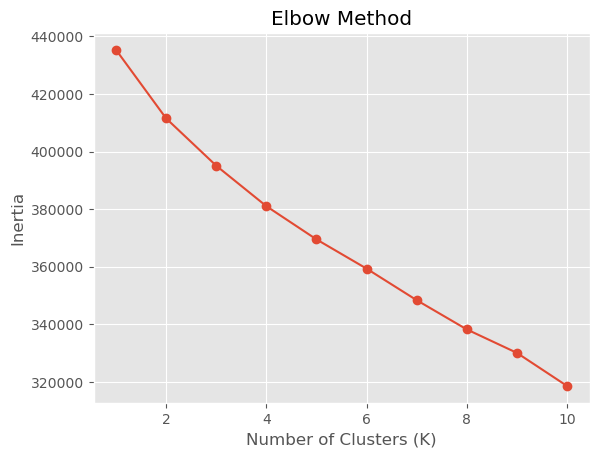

In [81]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans_scaled)
    inertia.append(kmeans.inertia_)


plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [82]:
pwd

'C:\\Users\\sweid'

In [83]:
pwd

'C:\\Users\\sweid'

In [84]:

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_kmeans_scaled)


df['Cluster'] = clusters

In [85]:
from sklearn.cluster import KMeans

# Drop targets
X_kmeans = df.drop(['poutcome', 'deposit'], axis=1, errors='ignore')

# Encode
X_kmeans = pd.get_dummies(X_kmeans, drop_first=True)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_kmeans_scaled)

In [86]:
# comparison
comparison = pd.crosstab(df['Cluster'], df['poutcome'])

print(comparison)

poutcome  failure  other  success  unknown
Cluster                                   
0              78     37      147      576
1             426    192      442     2432
2             500    238      434     2944
3             224     70       48     2374


# Supervised Learning

### neural network (mlpclassifier use)

In [90]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. X and y
X = df.drop('poutcome', axis=1)
y = df['poutcome']

# 2. Encodeor 
le = LabelEncoder()
y = le.fit_transform(y)


X = pd.get_dummies(X, drop_first=True)

# 4. Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# 5. Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [110]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(100,), 
    activation='relu',
    solver='adam', 
    max_iter=650,  
    random_state=42)
nn_model.fit(X_train, y_train)

# Predict
y_pred_nn = nn_model.predict(X_test)

In [ ]:
#Random forest classifier for Sampling  :

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Accuracy test 

In [98]:
from sklearn.metrics import accuracy_score

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Neural Network Accuracy: 0.8669950738916257
Random Forest Accuracy: 0.9140170174652933


In [ ]:
#  Hyperparameter Tuning and kfold stratified cross validation:

In [99]:
pwd

'C:\\Users\\sweid'

In [100]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [101]:
# Grid Search 

In [104]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(max_iter=600, random_state=42)

param_grid_nn = {
    'hidden_layer_sizes': [(50,), (100,)],
    'learning_rate_init': [0.001],
    'batch_size': [32]
}

grid_nn = GridSearchCV(
    estimator=nn,
    param_grid=param_grid_nn,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

grid_nn.fit(X_train, y_train)

print("Best NN Parameters:", grid_nn.best_params_)

Best NN Parameters: {'batch_size': 32, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}


In [105]:
# Random forest :
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 150],
    'max_depth': [10, None]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='accuracy',
    n_jobs=1
)

grid_rf.fit(X_train, y_train)

print("Best RF Parameters:", grid_rf.best_params_)

Best RF Parameters: {'max_depth': 10, 'n_estimators': 150}


In [107]:
# Final Model

In [109]:
best_nn = grid_nn.best_estimator_
best_rf = grid_rf.best_estimator_

y_pred_nn = best_nn.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [111]:
# Accuracy Comparsion 
from sklearn.metrics import accuracy_score

# Neural Network
acc_nn = accuracy_score(y_test, y_pred_nn)
print("Neural Network Accuracy:", acc_nn)

# Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Neural Network Accuracy: 0.8696820420958352
Random Forest Accuracy: 0.9153605015673981


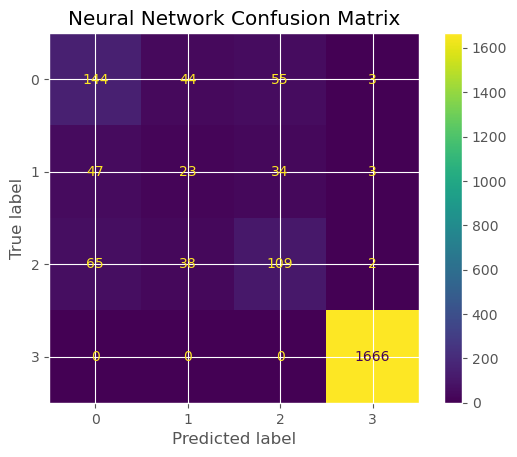

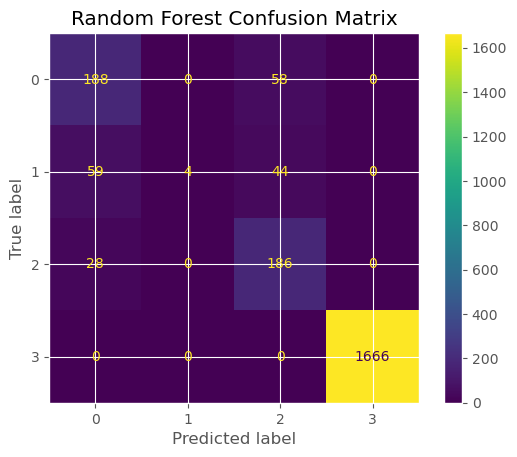

In [112]:
# Any Errors Happend or mistakes :
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Neural Network
cm_nn = confusion_matrix(y_test, y_pred_nn)
ConfusionMatrixDisplay(cm_nn).plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [113]:
# F1 Score per Class
from sklearn.metrics import classification_report

print("Neural Network Report:\n")
print(classification_report(y_test, y_pred_nn))

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf))


Neural Network Report:

              precision    recall  f1-score   support

           0       0.56      0.59      0.57       246
           1       0.22      0.21      0.22       107
           2       0.55      0.51      0.53       214
           3       1.00      1.00      1.00      1666

    accuracy                           0.87      2233
   macro avg       0.58      0.58      0.58      2233
weighted avg       0.87      0.87      0.87      2233

Random Forest Report:

              precision    recall  f1-score   support

           0       0.68      0.76      0.72       246
           1       1.00      0.04      0.07       107
           2       0.65      0.87      0.74       214
           3       1.00      1.00      1.00      1666

    accuracy                           0.92      2233
   macro avg       0.83      0.67      0.63      2233
weighted avg       0.93      0.92      0.90      2233



In [115]:
# macro vs micro 

In [114]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Neural Network
print("NN Macro Precision:", precision_score(y_test, y_pred_nn, average='macro'))
print("NN Macro Recall:", recall_score(y_test, y_pred_nn, average='macro'))
print("NN Macro F1:", f1_score(y_test, y_pred_nn, average='macro'))

print("NN Micro Precision:", precision_score(y_test, y_pred_nn, average='micro'))
print("NN Micro Recall:", recall_score(y_test, y_pred_nn, average='micro'))
print("NN Micro F1:", f1_score(y_test, y_pred_nn, average='micro'))

NN Macro Precision: 0.5818184242579404
NN Macro Recall: 0.5774162297697744
NN Macro F1: 0.5793543288424338
NN Micro Precision: 0.8696820420958352
NN Micro Recall: 0.8696820420958352
NN Micro F1: 0.8696820420958352


In [ ]:
# Test Vs Preformance 

In [116]:
# Neural Network
train_acc_nn = accuracy_score(y_train, best_nn.predict(X_train))
test_acc_nn = accuracy_score(y_test, y_pred_nn)

print("NN Train Accuracy:", train_acc_nn)
print("NN Test Accuracy:", test_acc_nn)

# Random Forest
train_acc_rf = accuracy_score(y_train, best_rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print("RF Train Accuracy:", train_acc_rf)
print("RF Test Accuracy:", test_acc_rf)

NN Train Accuracy: 0.9960801881509688
NN Test Accuracy: 0.8696820420958352
RF Train Accuracy: 0.9291074028446634
RF Test Accuracy: 0.9153605015673981


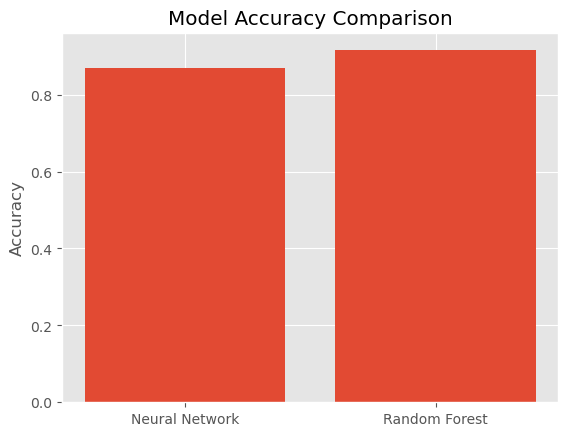

In [118]:
models = ['Neural Network', 'Random Forest']
accuracy = [acc_nn, acc_rf]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# All Tasks ARE DONE 

In [117]:
pwd

'C:\\Users\\sweid'

In [119]:
pwd

'C:\\Users\\sweid'